<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/Lab4_1_matplotlib_basics_Peru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización de Datos con Matplotlib
## Ciencia de Datos Ambientales – Aplicado al Perú

**Objetivos de aprendizaje:**
- Comprender la estructura de las figuras de Matplotlib
- Crear gráficos de línea, dispersión y barras
- Personalizar la apariencia (colores, etiquetas, leyendas)
- Construir visualizaciones efectivas para datos ambientales peruanos

**Entorno:** Google Colab

---

In [ ]:
# Importaciones estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## 1. ¿Por qué visualizar datos?

La visualización nos ayuda a:
- **Explorar** patrones y relaciones en los datos
- **Comunicar** hallazgos a otros
- **Detectar** valores atípicos y problemas de calidad de datos

Veamos un ejemplo donde la visualización revela algo que la estadística sola no puede mostrar.

In [ ]:
# Cuarteto de Anscombe – cuatro conjuntos de datos con estadísticas casi idénticas
# pero patrones muy diferentes

anscombe = {
    'I':   {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
            'y': [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]},
    'II':  {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
            'y': [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]},
    'III': {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
            'y': [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]},
    'IV':  {'x': [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
            'y': [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]}
}

# Los cuatro tienen casi idénticas: media(x)=9, media(y)≈7.5, correlación≈0.82
print("Los cuatro conjuntos tienen estadísticas casi idénticas:")
for nombre, datos in anscombe.items():
    r = np.corrcoef(datos['x'], datos['y'])[0,1]
    print(f"  {nombre}: media_x={np.mean(datos['x']):.1f}, media_y={np.mean(datos['y']):.2f}, r={r:.2f}")

Los cuatro conjuntos tienen estadísticas casi idénticas:
  I: media_x=9.0, media_y=7.50, r=0.82
  II: media_x=9.0, media_y=7.50, r=0.82
  III: media_x=9.0, media_y=7.50, r=0.82
  IV: media_x=9.0, media_y=7.50, r=0.82


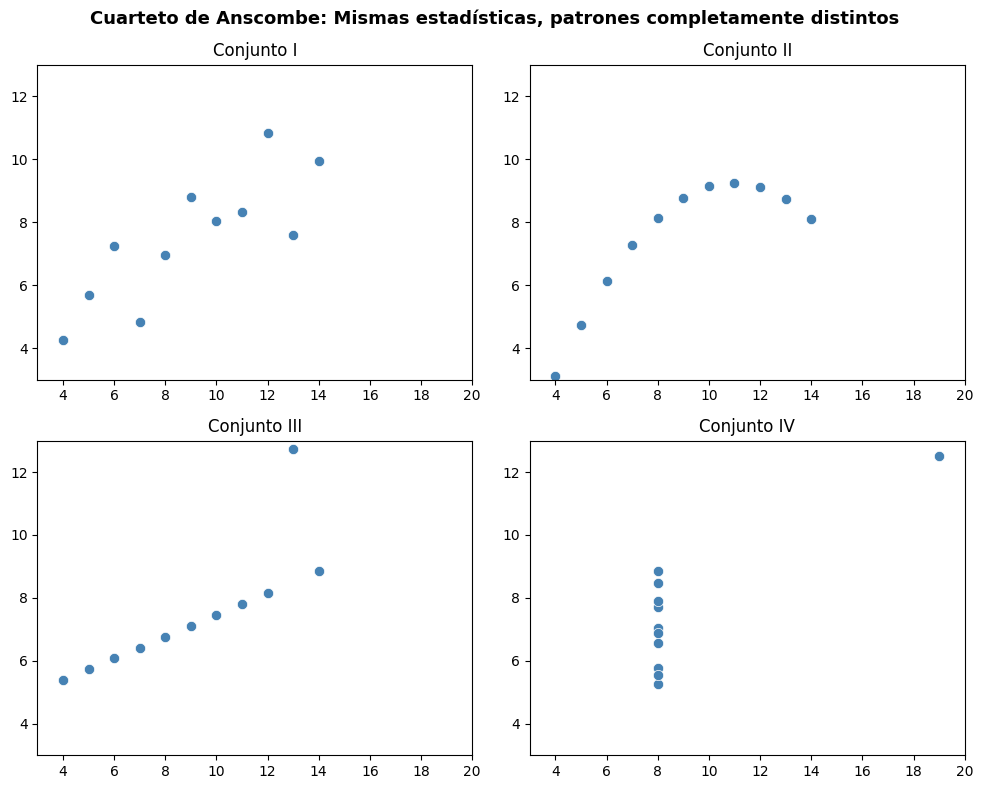


→ ¡Siempre visualiza tus datos!


In [ ]:
# Pero cuando los graficamos...
fig, ejes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (nombre, datos) in zip(ejes.flat, anscombe.items()):
    ax.scatter(datos['x'], datos['y'], s=55, color='steelblue', edgecolors='white', linewidths=0.5)
    ax.set_title(f'Conjunto {nombre}', fontsize=12)
    ax.set_xlim(3, 20)
    ax.set_ylim(3, 13)

plt.suptitle("Cuarteto de Anscombe: Mismas estadísticas, patrones completamente distintos",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n→ ¡Siempre visualiza tus datos!")

---
## 2. Fundamentos de Matplotlib

### 2.1 La Figura y los Ejes

Matplotlib tiene dos conceptos principales:
- **Figure** (`fig`): El lienzo completo (la ventana)
- **Axes** (`ax`): Un área de gráfico dentro de la figura

Piensa en ello como un marco de cuadro (Figure) que puede contener una o más imágenes (Axes).

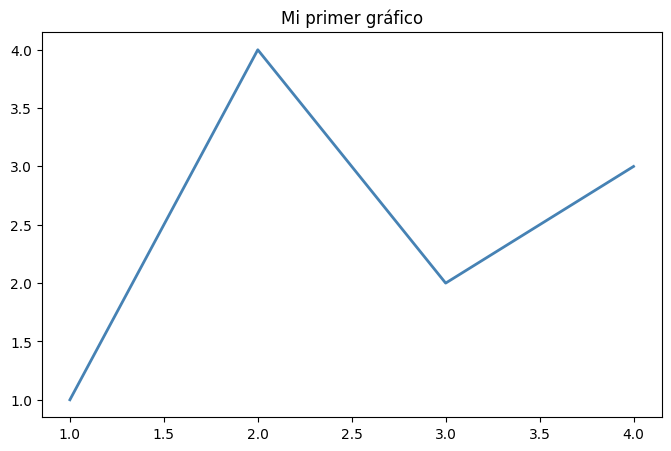

In [ ]:
# La forma recomendada: crear figura y ejes juntos
fig, ax = plt.subplots(figsize=(8, 5))  # figsize=(ancho, alto) en pulgadas

# Usar 'ax' para graficar
ax.plot([1, 2, 3, 4], [1, 4, 2, 3], color='steelblue', linewidth=2)
ax.set_title('Mi primer gráfico')

plt.show()

### 2.2 Elementos esenciales de un gráfico

Todo buen gráfico necesita:
- **Datos**: Los valores que se grafican
- **Etiquetas de ejes**: Qué representa cada eje (¡con unidades!)
- **Título**: Qué muestra el gráfico
- **Leyenda** (si hay múltiples series)

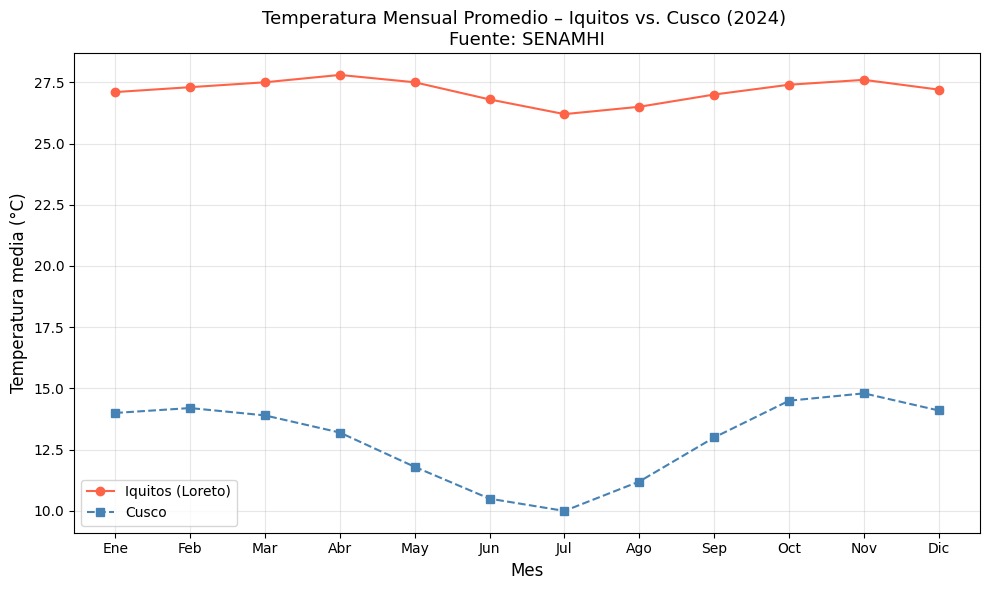

In [ ]:
# Un gráfico completo y bien etiquetado
# Temperatura mensual promedio en dos ciudades peruanas (datos SENAMHI)
fig, ax = plt.subplots(figsize=(10, 6))

meses = np.arange(1, 13)
temp_iquitos = [27.1, 27.3, 27.5, 27.8, 27.5, 26.8, 26.2, 26.5, 27.0, 27.4, 27.6, 27.2]
temp_cusco   = [14.0, 14.2, 13.9, 13.2, 11.8, 10.5, 10.0, 11.2, 13.0, 14.5, 14.8, 14.1]

# Graficar datos
ax.plot(meses, temp_iquitos, 'o-', color='tomato',  label='Iquitos (Loreto)')
ax.plot(meses, temp_cusco,   's--', color='steelblue', label='Cusco')

# Etiquetas y título
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Temperatura media (°C)', fontsize=12)
ax.set_title('Temperatura Mensual Promedio – Iquitos vs. Cusco (2024) \nFuente: SENAMHI',
             fontsize=13)

# Leyenda
ax.legend(fontsize=10)

# Mostrar nombres de meses
ax.set_xticks(meses)
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])

# Cuadrícula
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Preparar Conjuntos de Datos de Muestra

Usaremos estos conjuntos de datos ambientales peruanos a lo largo de la clase.

In [ ]:
# Conjunto 1: Monitoreo diario del río Ucayali (estación Pucallpa – SENAMHI)
np.random.seed(42)

fechas     = pd.date_range('2024-01-01', '2024-12-31', freq='D')
n_dias     = len(fechas)
dia_del_anio = np.arange(n_dias)

# Patrón estacional de temperatura (verano amazónico = más caluroso)
temp_estacional = 28 + 3 * np.sin(2 * np.pi * (dia_del_anio - 30) / 365)

# Caudal: alto en época de lluvias (Ene-Mar), bajo en vaciante (Jun-Sep)
caudal_base = 2000 + 1500 * np.sin(2 * np.pi * (dia_del_anio - 45) / 365)

datos_rio = pd.DataFrame({
    'fecha'          : fechas,
    'temperatura_c'  : temp_estacional + np.random.normal(0, 1.5, n_dias),
    'caudal_m3s'     : np.maximum(caudal_base + np.random.normal(0, 300, n_dias), 50),
    'turbidez_ntu'   : np.maximum(120 + 80 * np.sin(2 * np.pi * (dia_del_anio - 45) / 365)
                                  + np.random.normal(0, 30, n_dias), 10)
})

print("Datos del río Ucayali (Pucallpa):")
datos_rio.head()

Datos del río Ucayali (Pucallpa):


,fecha,temperatura_c,caudal_m3s,turbidez_ntu
0,2024-01-01,27.263745,1018.040254,76.290917
1,2024-01-02,26.356402,973.198569,13.958270
2,2024-01-03,27.580882,1017.637401,96.919180
3,2024-01-04,28.939857,775.645137,81.247155
4,2024-01-05,26.350443,1034.408711,75.790527


In [ ]:
# Conjunto 2: Inventario forestal – Madre de Dios (SERFOR)
np.random.seed(123)
n_arboles = 100

datos_arboles = pd.DataFrame({
    'especie': np.random.choice(
        ['Swietenia macrophylla', 'Cedrela odorata',
         'Cedrelinga cateniformis', 'Virola surinamensis'],
        n_arboles, p=[0.30, 0.35, 0.25, 0.10]),
    'dap_cm': np.random.uniform(15, 70, n_arboles)
})
datos_arboles['altura_m'] = (6 + 0.42 * datos_arboles['dap_cm']
                              + np.random.normal(0, 3.5, n_arboles)).clip(lower=4)

print("Inventario forestal (Madre de Dios):")
datos_arboles.head()

Inventario forestal (Madre de Dios):


,especie,dap_cm,altura_m
0,Cedrelinga cateniformis,43.222048,21.560412
1,Swietenia macrophylla,51.664350,27.954202
2,Swietenia macrophylla,20.824967,16.157287
3,Cedrela odorata,22.199222,20.475426
4,Cedrelinga cateniformis,32.708933,20.813597


In [ ]:
# Conjunto 3: Cobertura de uso de suelo por región natural del Perú (MINAM)
cobertura_suelo = pd.DataFrame({
    'region'     : ['Costa', 'Sierra', 'Selva Alta', 'Selva Baja', 'Mar Peruano'],
    'bosque'     : [2, 12, 58, 72, 0],
    'agricultura': [45, 38, 18, 8, 0],
    'urbano'     : [28, 12, 5, 3, 0],
    'agua'       : [5, 8, 12, 15, 100],
    'otro'       : [20, 30, 7, 2, 0]
})

print("Cobertura de uso de suelo (%):")
cobertura_suelo

Cobertura de uso de suelo (%):


,region,bosque,agricultura,urbano,agua,otro
0,Costa,2,45,28,5,20
1,Sierra,12,38,12,8,30
2,Selva Alta,58,18,5,12,7
3,Selva Baja,72,8,3,15,2
4,Mar Peruano,0,0,0,100,0


---
## 4. Gráficos de Línea

**Ideales para:** Series de tiempo, tendencias continuas, mostrar cambio a lo largo de una secuencia

### 4.1 Gráfico de línea básico

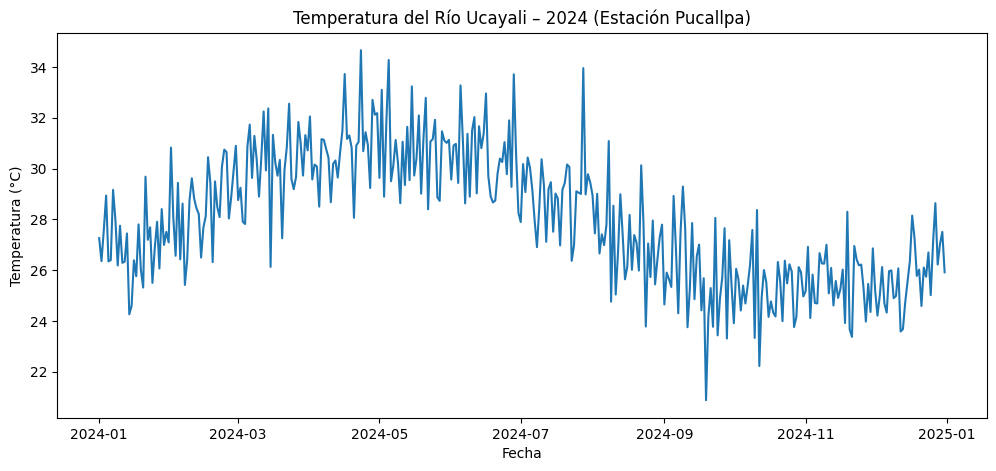

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(datos_rio['fecha'], datos_rio['temperatura_c'])

ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Temperatura del Río Ucayali – 2024 (Estación Pucallpa)')

plt.show()

### 4.2 Estilos de línea y colores

Cadena de formato: `'color + marcador + estilo de línea'`

| Colores | Marcadores | Estilos de línea |
|---------|------------|-----------------|
| `b` azul | `o` círculo | `-` sólida |
| `g` verde | `s` cuadrado | `--` discontinua |
| `r` rojo | `^` triángulo | `:` punteada |
| `k` negro | `d` diamante | `-.` punto-raya |

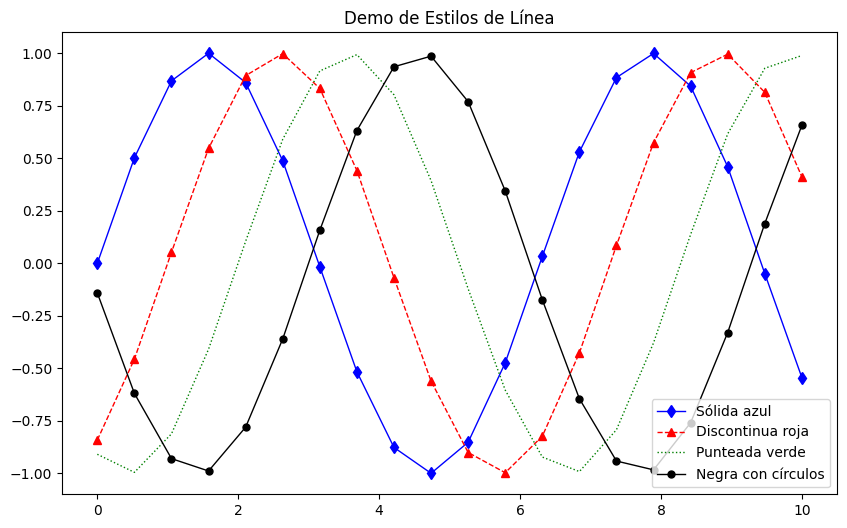

In [ ]:
# Demostración de distintos estilos
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 10, 20)

ax.plot(x, np.sin(x),       'bd-',  linewidth=1, label='Sólida azul')
ax.plot(x, np.sin(x - 1),   'r^--', linewidth=1, label='Discontinua roja')
ax.plot(x, np.sin(x - 2),   'g:',  linewidth=1, label='Punteada verde')
ax.plot(x, np.sin(x - 3),   'ko-', linewidth=1, markersize=5, label='Negra con círculos')

ax.legend()
ax.set_title('Demo de Estilos de Línea')

plt.show()

### 4.3 Añadir líneas de referencia

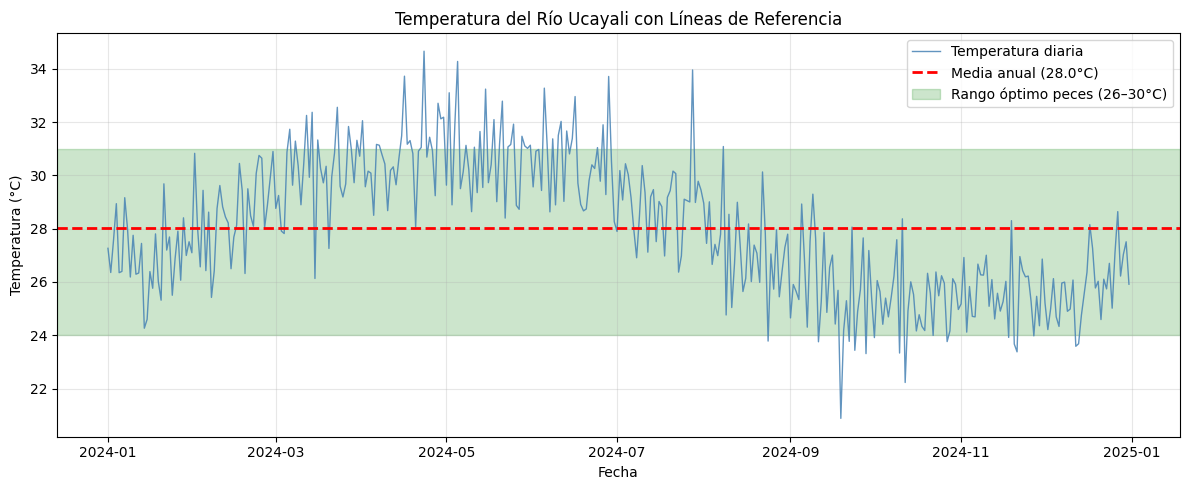

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

# Graficar datos principales
ax.plot(datos_rio['fecha'], datos_rio['temperatura_c'],
        color='steelblue', linewidth=1, alpha=0.85, label='Temperatura diaria')

# Línea horizontal de referencia (media anual)
temp_media = datos_rio['temperatura_c'].mean()
ax.axhline(y=temp_media, color='red', linestyle='--', linewidth=2,
           label=f'Media anual ({temp_media:.1f}°C)')

# Región sombreada: rango óptimo para peces de agua dulce amazónicos
ax.axhspan(24, 31, color='green', alpha=0.2, label='Rango óptimo peces (26–30°C)')

ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Temperatura del Río Ucayali con Líneas de Referencia')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🔬 Ejercicio rápido 1 – Gráfico de línea

Usando `datos_rio`, crea un gráfico de línea del **caudal** (`caudal_m3s`) a lo largo del año.

1. Usa color `'darkorange'`
2. Añade una línea horizontal con el caudal medio
3. Sombrea en azul claro la **época de creciente** (enero–abril, aproximadamente días 0–120)
4. Incluye etiquetas de ejes y título apropiados

In [ ]:
# Tu código aquí

# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(...)
# ax.axhline(...)
# ax.axvspan(...)

---
## 5. Gráficos de Dispersión

**Ideales para:** Mostrar relaciones entre dos variables continuas

### 5.1 Gráfico de dispersión básico

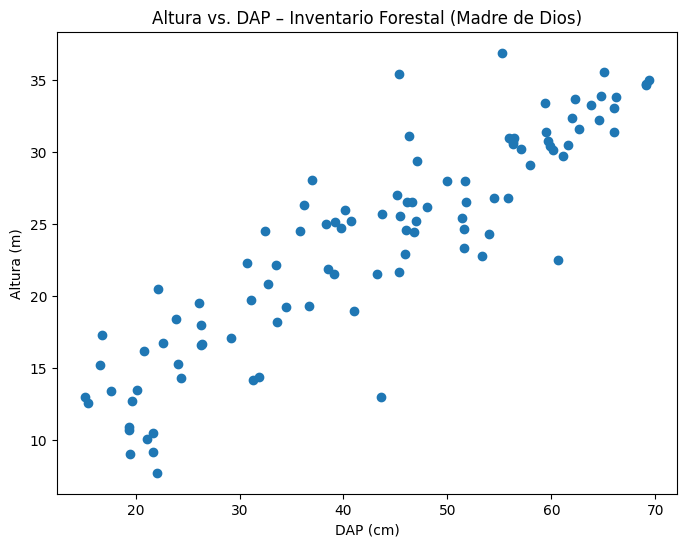

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(datos_arboles['dap_cm'], datos_arboles['altura_m'])

ax.set_xlabel('DAP (cm)')
ax.set_ylabel('Altura (m)')
ax.set_title('Altura vs. DAP – Inventario Forestal (Madre de Dios)')

plt.show()

### 5.2 Personalizar gráficos de dispersión

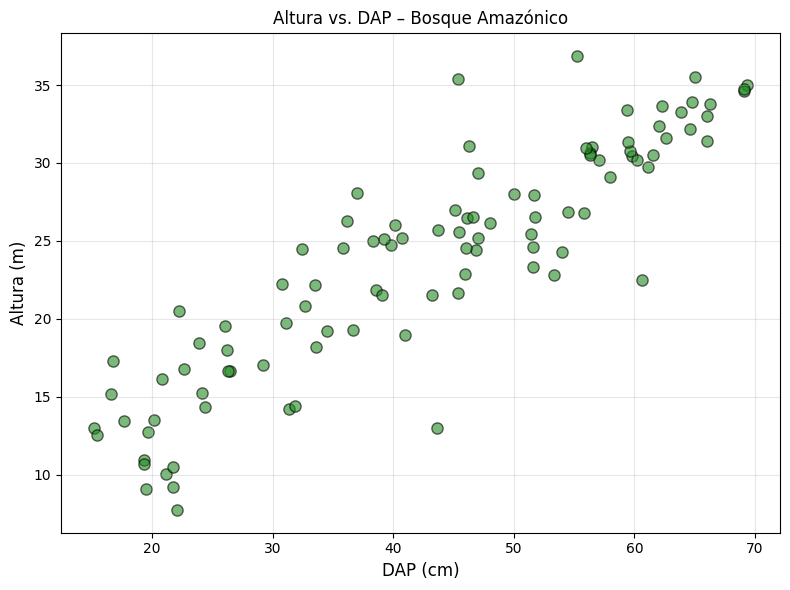

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(datos_arboles['dap_cm'], datos_arboles['altura_m'],
           s=65,                # tamaño del marcador
           c='forestgreen',     # color
           alpha=0.6,           # transparencia
           edgecolors='black',  # color del borde
           linewidths=1)      # grosor del borde

ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_ylabel('Altura (m)', fontsize=12)
ax.set_title('Altura vs. DAP – Bosque Amazónico', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Color por categoría

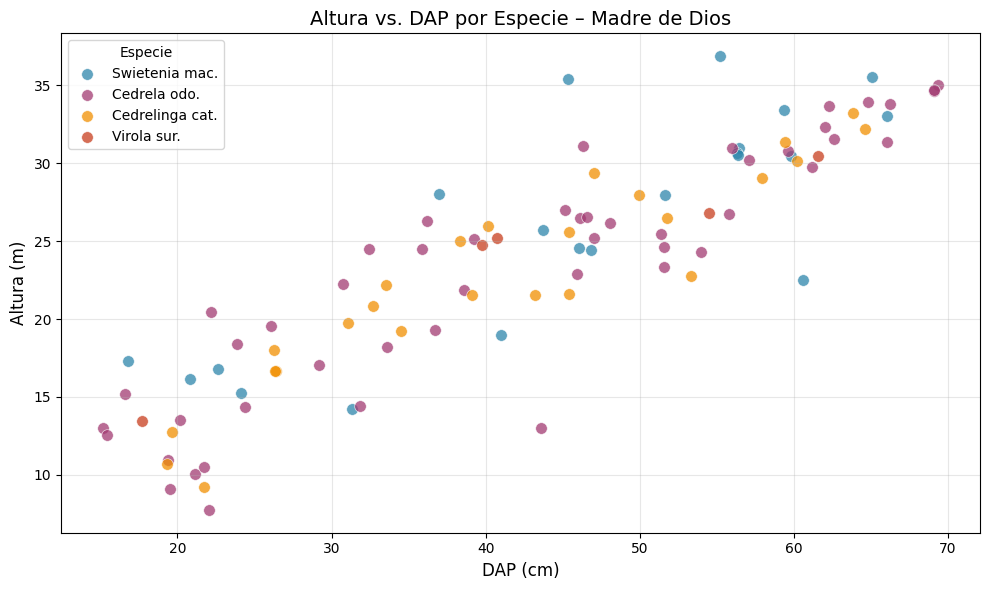

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Definir un color por especie
colores_especie = {
    'Swietenia macrophylla'    : '#2E86AB',   # caoba
    'Cedrela odorata'          : '#A23B72',   # cedro
    'Cedrelinga cateniformis'  : '#F18F01',   # tornillo
    'Virola surinamensis'      : '#C73E1D'    # cumala
}

# Graficar cada especie por separado para crear leyenda
for especie, color in colores_especie.items():
    subset = datos_arboles[datos_arboles['especie'] == especie]
    nombre_corto = especie.split()[0] + ' ' + especie.split()[1][:3] + '.'
    ax.scatter(subset['dap_cm'], subset['altura_m'],
               s=70, c=color, label=nombre_corto,
               alpha=0.75, edgecolors='white', linewidths=0.5)

ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_ylabel('Altura (m)', fontsize=12)
ax.set_title('Altura vs. DAP por Especie – Madre de Dios', fontsize=14)
ax.legend(title='Especie', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Color por variable continua (barra de color)

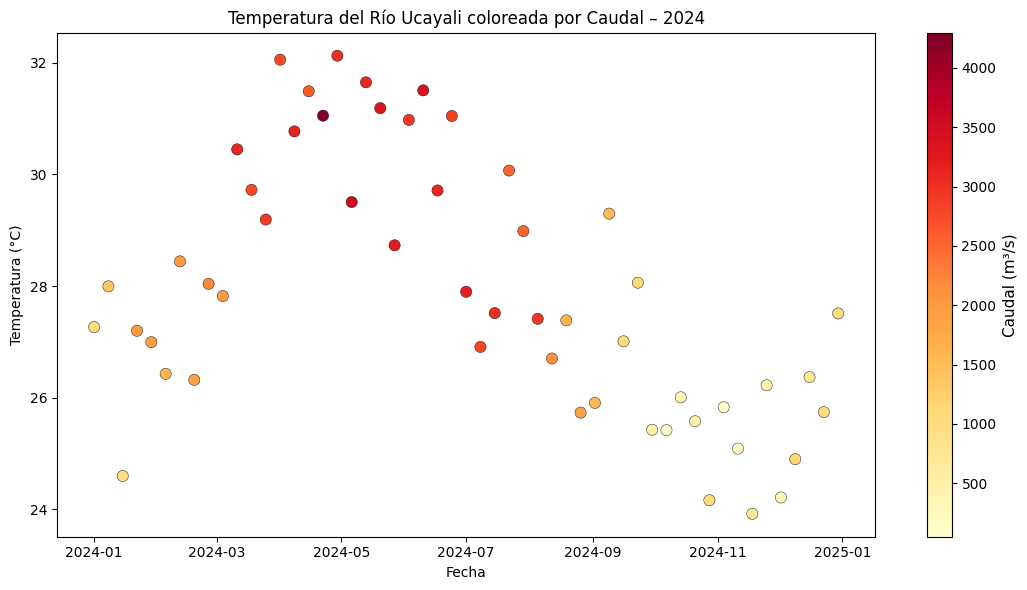

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

# Usar datos semanales para una visualización más clara
semanal = datos_rio.iloc[::7]  # Cada 7 filas

scatter = ax.scatter(semanal['fecha'], semanal['temperatura_c'],
                     c=semanal['caudal_m3s'],   # Color según caudal
                     s=65,
                     cmap='YlOrRd',              # Mapa de color
                     edgecolors='black',
                     linewidths=0.3)

# Añadir barra de color
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Caudal (m³/s)', fontsize=11)

ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Temperatura del Río Ucayali coloreada por Caudal – 2024')

plt.tight_layout()
plt.show()

### 🔬 Ejercicio rápido 2 – Dispersión con color por categoría

Usa el inventario forestal `datos_arboles` para crear un gráfico de dispersión de **DAP vs. altura**, pero esta vez:

1. Colorea los puntos por especie (define tus propios colores)
2. Añade una **línea de regresión** general (usa `np.polyfit` o `scipy.stats.linregress`)
3. Anota en el gráfico el valor de r² de la regresión
4. Añade etiquetas y título apropiados

In [ ]:
# Tu código aquí
from scipy import stats

# pendiente, intercepto, r, p, _ = stats.linregress(???)
# r2 = r**2

# fig, ax = plt.subplots(figsize=(9, 6))
# for especie, color in colores_especie.items():
#     ...
# ax.plot(...)   # línea de regresión
# ax.text(...)   # anotar r²

---
## 6. Gráficos de Barras

**Ideales para:** Comparar cantidades entre categorías discretas

### 6.1 Gráfico de barras básico

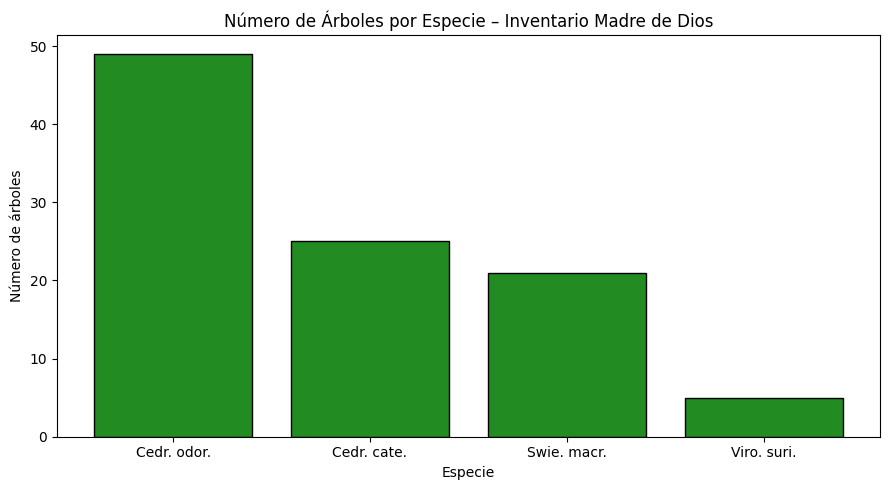

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

conteo_especies = datos_arboles['especie'].value_counts()
etiquetas_cortas = [e.split()[0][:4]+'. '+e.split()[1][:4]+'.'
                    for e in conteo_especies.index]

ax.bar(etiquetas_cortas, conteo_especies.values,
       color='forestgreen', edgecolor='black')

ax.set_xlabel('Especie')
ax.set_ylabel('Número de árboles')
ax.set_title('Número de Árboles por Especie – Inventario Madre de Dios')

plt.tight_layout()
plt.show()

### 6.2 Añadir etiquetas de valor

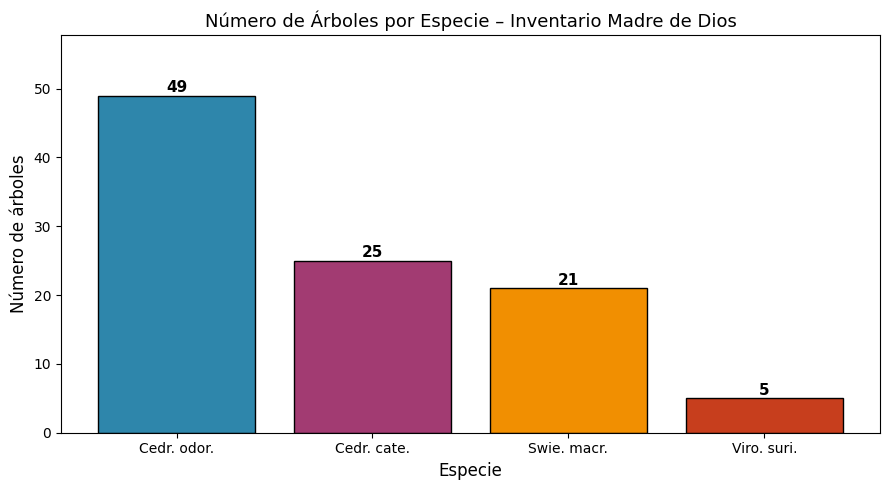

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

conteo_especies = datos_arboles['especie'].value_counts()
etiquetas_cortas = [e.split()[0][:4]+'. '+e.split()[1][:4]+'.'
                    for e in conteo_especies.index]
colores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

barras = ax.bar(etiquetas_cortas, conteo_especies.values,
                color=colores, edgecolor='black')

# Añadir etiquetas de valor encima de cada barra
for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + 0.5,
            f'{int(altura)}', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Especie', fontsize=12)
ax.set_ylabel('Número de árboles', fontsize=12)
ax.set_title('Número de Árboles por Especie – Inventario Madre de Dios', fontsize=13)
ax.set_ylim(0, conteo_especies.max() * 1.18)

plt.tight_layout()
plt.show()

### 6.3 Gráfico de barras agrupadas

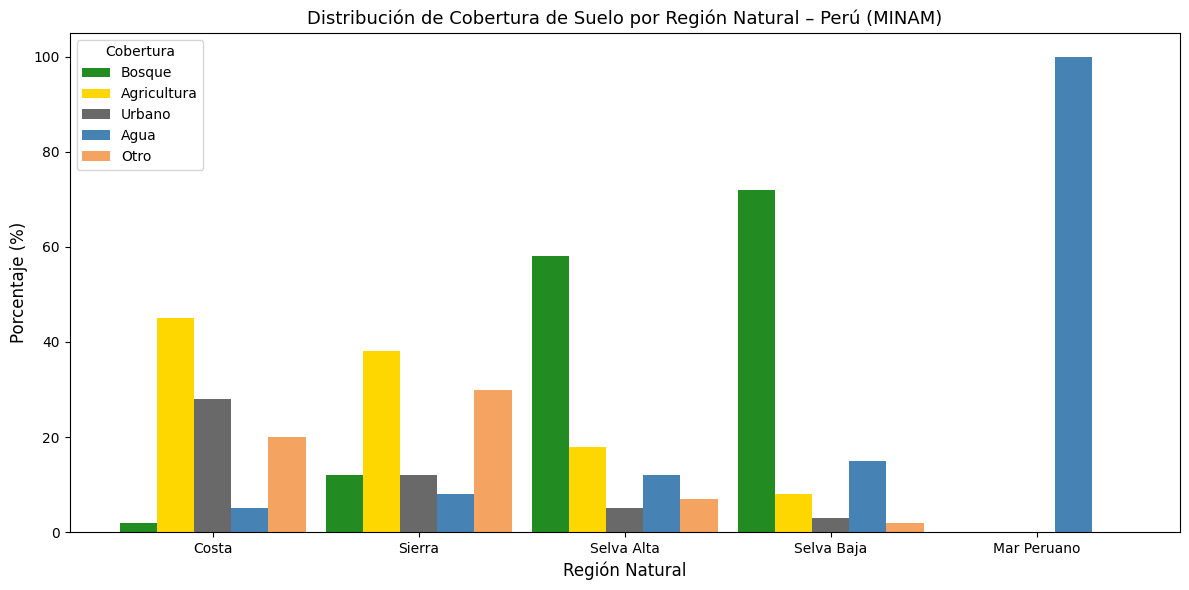

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

regiones = cobertura_suelo['region']
x     = np.arange(len(regiones))
ancho = 0.18

ax.bar(x - 2*ancho, cobertura_suelo['bosque'],      ancho, label='Bosque',     color='forestgreen')
ax.bar(x - 1*ancho, cobertura_suelo['agricultura'], ancho, label='Agricultura', color='gold')
ax.bar(x + 0*ancho, cobertura_suelo['urbano'],      ancho, label='Urbano',      color='dimgray')
ax.bar(x + 1*ancho, cobertura_suelo['agua'],        ancho, label='Agua',        color='steelblue')
ax.bar(x + 2*ancho, cobertura_suelo['otro'],        ancho, label='Otro',        color='sandybrown')

ax.set_xlabel('Región Natural', fontsize=12)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('Distribución de Cobertura de Suelo por Región Natural – Perú (MINAM)',
             fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(regiones)
ax.legend(title='Cobertura')

plt.tight_layout()
plt.show()

### 6.4 Gráfico de barras horizontales

Mejor cuando los nombres de categorías son largos.

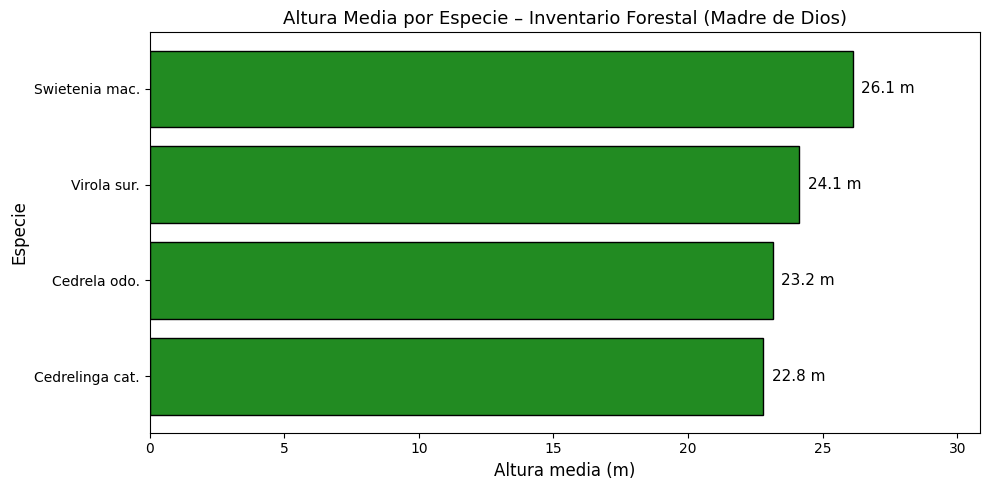

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Altura media por especie
altura_media = (datos_arboles.groupby('especie')['altura_m']
                .mean()
                .sort_values())

# Abreviar nombres de especie para el gráfico
nombres_cortos = [e.split()[0]+' '+e.split()[1][:3]+'.' for e in altura_media.index]

ax.barh(nombres_cortos, altura_media.values, color='forestgreen', edgecolor='black')

# Añadir etiquetas de valor
for i, (nombre, altura) in enumerate(zip(nombres_cortos, altura_media.values)):
    ax.text(altura + 0.3, i, f'{altura:.1f} m', va='center', fontsize=11)

ax.set_xlabel('Altura media (m)', fontsize=12)
ax.set_ylabel('Especie', fontsize=12)
ax.set_title('Altura Media por Especie – Inventario Forestal (Madre de Dios)', fontsize=13)
ax.set_xlim(0, altura_media.max() * 1.18)

plt.tight_layout()
plt.show()

### 🔬 Ejercicio rápido 3 – Barras agrupadas

El MINAM reporta la deforestación acumulada (ha) en tres regiones amazónicas del Perú durante tres períodos:

```python
regiones  = ['Madre de Dios', 'Ucayali', 'Loreto']
per_2015  = [12500, 28300, 18700]
per_2019  = [15800, 31200, 22400]
per_2023  = [18200, 35700, 26100]
```

Crea un gráfico de barras agrupadas que muestre la deforestación por región y período.
Añade etiquetas de valor encima de cada barra y colorea los períodos de menor a mayor intensidad (ej. tonos de rojo).

In [ ]:
# Tu código aquí
regiones = ['Madre de Dios', 'Ucayali', 'Loreto']
per_2015 = [12500, 28300, 18700]
per_2019 = [15800, 31200, 22400]
per_2023 = [18200, 35700, 26100]

# fig, ax = plt.subplots(figsize=(11, 6))
# x = np.arange(len(regiones))
# ancho = 0.25
# ax.bar(...)

---
## 7. Múltiples subgráficos

Un panel de subgráficos permite mostrar varios gráficos relacionados en una sola figura.

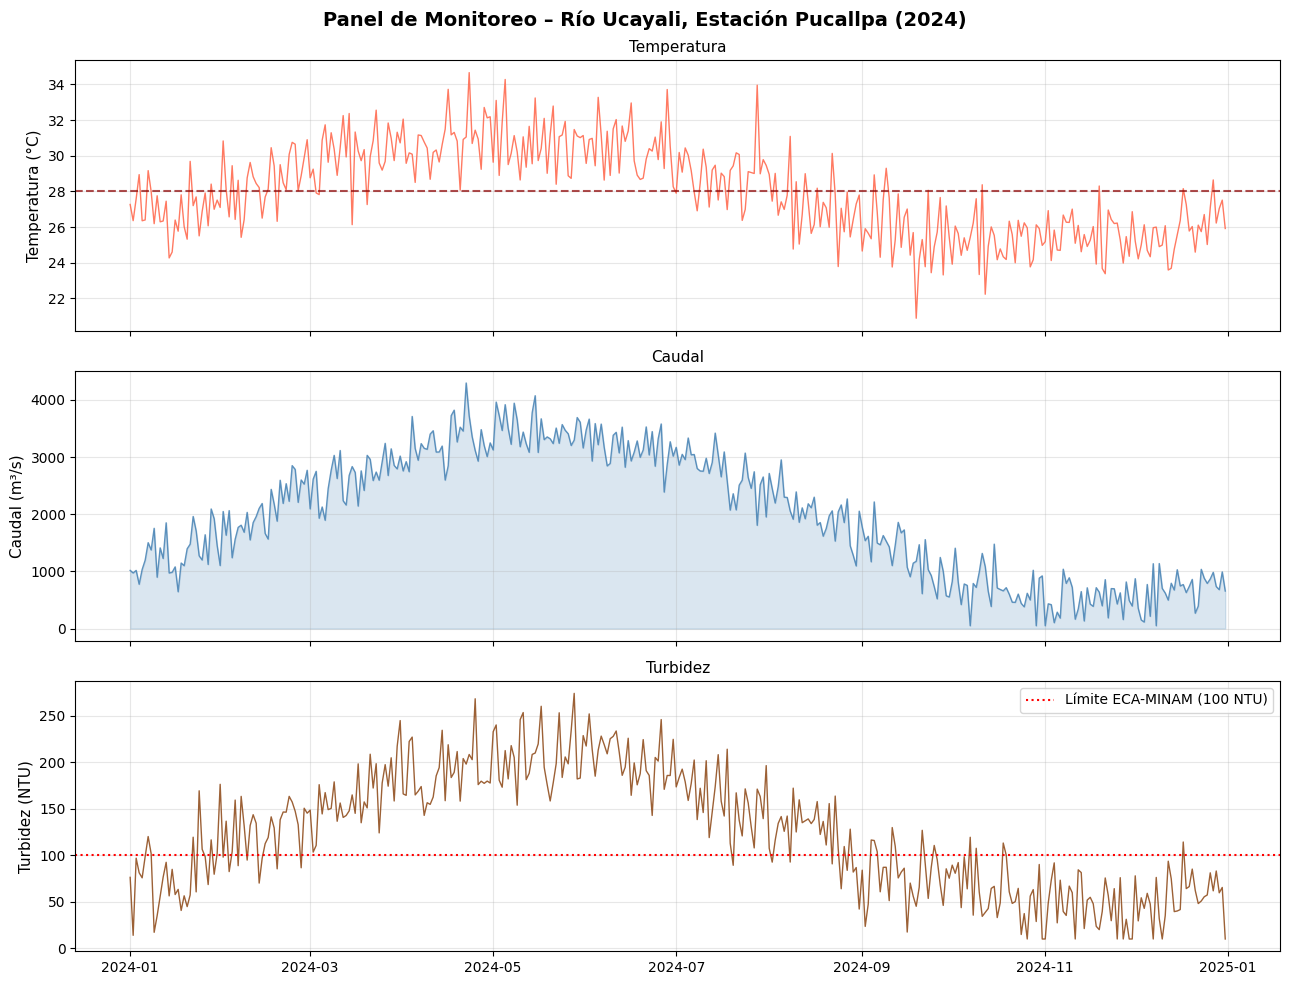

In [ ]:
# Panel de monitoreo ambiental del río Ucayali
fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# ── Temperatura ──
ax[0].plot(datos_rio['fecha'], datos_rio['temperatura_c'],
             color='tomato', linewidth=1, alpha=0.85)
ax[0].axhline(datos_rio['temperatura_c'].mean(), color='darkred',
                linestyle='--', linewidth=1.5, alpha=0.7)
ax[0].set_ylabel('Temperatura (°C)', fontsize=11)
ax[0].set_title('Temperatura', fontsize=11)
ax[0].grid(True, alpha=0.3)

# ── Caudal ──
ax[1].plot(datos_rio['fecha'], datos_rio['caudal_m3s'],
             color='steelblue', linewidth=1, alpha=0.85)
ax[1].fill_between(datos_rio['fecha'], datos_rio['caudal_m3s'],
                     alpha=0.2, color='steelblue')
ax[1].set_ylabel('Caudal (m³/s)', fontsize=11)
ax[1].set_title('Caudal', fontsize=11)
ax[1].grid(True, alpha=0.3)

# ── Turbidez ──
ax[2].plot(datos_rio['fecha'], datos_rio['turbidez_ntu'],
             color='saddlebrown', linewidth=1, alpha=0.85)
ax[2].axhline(100, color='red', linestyle=':', linewidth=1.5,
                label='Límite ECA-MINAM (100 NTU)')
ax[2].set_ylabel('Turbidez (NTU)', fontsize=11)
ax[2].set_title('Turbidez', fontsize=11)
ax[2].legend(fontsize=10)
ax[2].grid(True, alpha=0.3)

fig.suptitle('Panel de Monitoreo – Río Ucayali, Estación Pucallpa (2024)',
             fontsize=14, fontweight='bold')
fig.savefig('panel_monitoreo_rio.png')
plt.tight_layout()
plt.show()

### 🔬 Ejercicio integrador – Panel de visualización completo

Usando los tres conjuntos de datos (`datos_rio`, `datos_arboles`, `cobertura_suelo`), crea una figura con **2 filas × 2 columnas** que incluya:

1. **(Superior izquierda)** Línea de temperatura del río con media y zona de confort térmico
2. **(Superior derecha)** Dispersión DAP vs. Altura coloreada por especie
3. **(Inferior izquierda)** Barras de cobertura de suelo para la región **Selva Baja**
4. **(Inferior derecha)** Barras horizontales de altura media por especie

Asegúrate de que cada subgráfico tenga título, etiquetas de ejes y cuadrícula.

In [ ]:
# Tu código aquí
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

# ── (0,0) Temperatura ──
# ejes[0,0].plot(...)

# ── (0,1) Dispersión ──
# for especie, color in colores_especie.items():
#     ...

# ── (1,0) Barras cobertura Selva Baja ──
# fila_selva = cobertura_suelo[cobertura_suelo['region'] == 'Selva Baja'].iloc[0]
# ...

# ── (1,1) Barras horizontales altura media ──
# ...

plt.suptitle('Panel de Análisis Ambiental – Perú', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Resumen

| Tipo de gráfico | Ideal para | Función |
|-----------------|------------|---------|
| Línea           | Series de tiempo, tendencias | `ax.plot()` |
| Dispersión      | Relaciones entre variables   | `ax.scatter()` |
| Barras          | Comparar categorías          | `ax.bar()`, `ax.barh()` |
| Subgráficos     | Paneles multi-variable       | `plt.subplots(n, m)` |

**Elementos esenciales en todo gráfico:**
- Etiquetas de ejes con unidades
- Título descriptivo
- Leyenda (cuando hay múltiples series)
- Cuadrícula para legibilidad

**Próxima clase:** Histogramas, Seaborn y guardar figuras

---
## Soluciones

In [ ]:
# Solución Ejercicio rápido 1 – Caudal del río Ucayali
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(datos_rio['fecha'], datos_rio['caudal_m3s'],
        color='darkorange', linewidth=1, alpha=0.85, label='Caudal diario')

caudal_medio = datos_rio['caudal_m3s'].mean()
ax.axhline(y=caudal_medio, color='darkred', linestyle='--', linewidth=2,
           label=f'Caudal medio ({caudal_medio:.0f} m³/s)')

# Época de creciente (Ene–Abr ≈ días 0–120)
ax.axvspan(datos_rio['fecha'].iloc[0], datos_rio['fecha'].iloc[120],
           color='steelblue', alpha=0.12, label='Época de creciente')

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Caudal (m³/s)', fontsize=12)
ax.set_title('Caudal del Río Ucayali – Estación Pucallpa (2024)', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Solución Ejercicio rápido 2 – Dispersión con regresión
from scipy import stats as sp_stats

fig, ax = plt.subplots(figsize=(9, 6))

colores_especie = {
    'Swietenia macrophylla'   : '#2E86AB',
    'Cedrela odorata'         : '#A23B72',
    'Cedrelinga cateniformis' : '#F18F01',
    'Virola surinamensis'     : '#C73E1D'
}

for especie, color in colores_especie.items():
    sub = datos_arboles[datos_arboles['especie'] == especie]
    nombre = especie.split()[0][0]+'. '+especie.split()[1][:4]+'.'
    ax.scatter(sub['dap_cm'], sub['altura_m'], s=65, c=color,
               label=nombre, alpha=0.7, edgecolors='white', linewidths=0.4)

# Línea de regresión general
m, b, r, p, _ = sp_stats.linregress(datos_arboles['dap_cm'], datos_arboles['altura_m'])
x_l = np.array([datos_arboles['dap_cm'].min(), datos_arboles['dap_cm'].max()])
ax.plot(x_l, m*x_l + b, 'k-', linewidth=2, label=f'Regresión (r²={r**2:.2f})')
ax.text(0.05, 0.92, f'r² = {r**2:.3f}', transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_ylabel('Altura (m)', fontsize=12)
ax.set_title('Altura vs. DAP por Especie – Inventario Forestal (Madre de Dios)', fontsize=13)
ax.legend(title='Especie', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Solución Ejercicio rápido 3 – Deforestación por región y período
regiones = ['Madre de Dios', 'Ucayali', 'Loreto']
per_2015 = [12500, 28300, 18700]
per_2019 = [15800, 31200, 22400]
per_2023 = [18200, 35700, 26100]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(regiones))
ancho = 0.25

barras_2015 = ax.bar(x - ancho, per_2015, ancho, label='2011–2015', color='#FFCCCC')
barras_2019 = ax.bar(x,         per_2019, ancho, label='2016–2019', color='#FF6666')
barras_2023 = ax.bar(x + ancho, per_2023, ancho, label='2020–2023', color='#CC0000')

for grupo in [barras_2015, barras_2019, barras_2023]:
    for barra in grupo:
        h = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, h + 200,
                f'{int(h):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(regiones, fontsize=12)
ax.set_xlabel('Región', fontsize=12)
ax.set_ylabel('Deforestación acumulada (ha)', fontsize=12)
ax.set_title('Deforestación Acumulada por Región Amazónica – Perú (MINAM)', fontsize=13)
ax.legend(title='Período')
ax.grid(True, alpha=0.2, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()